# Logistic Regression for multi-class problem

# 1. import

In [1]:
%matplotlib inline
import sklearn
from sklearn import datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# import os,sys
# sys.path.append(os.path.abspath('./')) #for import utility
from utility import plot_decision_regions
print(pd.__version__)
print(sklearn.__version__)

3.0.1
1.8.0


# 2. load data
## 載入Iris資料集


In [2]:
iris = datasets.load_iris()
# x = pd.DataFrame(iris['data'], columns=iris['feature_names'])
# print(iris['data'].size)
# print("target_names: "+str(iris['target_names']))
# y = pd.DataFrame(iris['target'], columns=['target'])
# iris_data = pd.concat([x,y], axis=1)
# iris_data = iris_data[['sepal length (cm)','petal length (cm)','target']]

X = pd.DataFrame(iris["data"], columns = iris["feature_names"])
y = pd.Series(iris["target"], name = "target")

In [3]:
display(X.head())
display(y.head())
print(X.shape, y.shape)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

(150, 4) (150,)


# 3. select features and train/test split

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X[['sepal length (cm)','petal length (cm)']], y, test_size=0.3, random_state=0)
# 可加入 stratify=y 參數，之後再研究一下
# 不篩選0,1，選擇多類別

In [5]:
# y_train.shape

In [6]:
# type(y_test)

# 4. Standardization

In [7]:
# 未來準備
# from sklearn.pipeline import Pipeline

# pipe = Pipeline([
#     ("scaler", StandardScaler()),
#     ("model", LogisticRegression())
# ])

# pipe.fit(X_train, y_train)
# pipe.score(X_test, y_test)

In [8]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler().fit(X_train)
X_train_std = pd.DataFrame(
    sc.transform(X_train),
    columns = X_train.columns,
    index = X_train.index
)
X_test_std = pd.DataFrame(
    sc.transform(X_test),
    columns = X_test.columns,
    index = X_test.index
)

In [9]:
X_train_std

,sepal length (cm),petal length (cm)
60,-1.023664,-0.182950
116,0.695175,0.930661
144,0.924353,1.042022
119,0.122229,0.652258
108,0.924353,1.097702
...,...,...
9,-1.138253,-1.296561
103,0.465996,0.986341
67,-0.106950,0.151133
117,2.070245,1.598827


# 5. model training

In [10]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(solver='lbfgs') # multi_class='auto' # multi_class=multinomial
# 現在已經不用寫入 multi_class 的參數
# 可考慮 max_iter=200，確保收斂

lr.fit(X_train_std, y_train)
print('training accuracy:',lr.score(X_train_std, y_train))
print('test accuracy:',lr.score(X_test_std, y_test))

training accuracy: 0.9619047619047619
test accuracy: 0.9555555555555556


In [11]:
X_test[:2]

,sepal length (cm),petal length (cm)
114,5.8,5.1
62,6.0,4.0


# 6. prediction

In [12]:
#prediction
y_pred = lr.predict(X_test_std)
print(y_pred)

[2 1 0 2 0 2 0 1 2 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 2 1 1 2 0 2 0 0]


In [13]:
#ground truth
print(y_test.values)

[2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 1 1 1 2 0 2 0 0]


In [14]:
# len(y_test.values)

In [15]:
# y_test

# 7. accuracy + error analysis

In [16]:
# error_index=np.where(y_pred != y_test.values)[0]
# print(X_test.index[24], X_test.index[37])
# 找出24與37筆資料的原始位置

# 後面 y_test 轉 numpy 避免吃到 index 去比較
# mask = y_pred != y_test.to_numpy()
# error_index = y_test.index[mask]

y_pred_series = pd.Series(y_pred, index=y_test.index, name="pred")
mask = y_pred_series != y_test
error_index = y_test[mask].index

In [17]:
# mask

In [18]:
# type(error_index)

In [25]:
# error_index=np.where(pred!=y_test.values)[0]
# print('accuracy:',1-len(error_index)/len(X_test))
# print('error_index:',error_index)
# print('miss classification :',pred[error_index])#錯誤答案
# data_index=X_test.iloc[error_index].index 
# iris_data.iloc[data_index]#錯誤欄位的正確之原始資料

# accuracy = (y_pred_series == y_test).mean()
# print("accuracy:", accuracy)
# print('accuracy:',1-len(error_index)/len(X_test))
# print('error_index:', error_index)
# display(df_error[mask])

print('miss classification :')
df_error = X_test.copy()
df_error["true"] = y_test
df_error["pred"] = y_pred_series
df_error["correct"] = df_error["true"] == df_error["pred"]

print("accuracy:", df_error["correct"].mean())
print("error_index:", df_error[~df_error["correct"]].index)

display(df_error[~df_error["correct"]])

miss classification :
accuracy: 0.9555555555555556
error_index: Index([76, 83], dtype='int64')


,sepal length (cm),petal length (cm),true,pred,correct
76,6.8,4.8,1,2,False
83,6.0,5.1,1,2,False


In [20]:
#iris_data.iloc[data_index]

In [21]:
# print(X.iloc[error_index])
# print(y.iloc[error_index])

# 8. visualization

## decision_regions for test data

/Users/wuyichan/IMLP-464/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


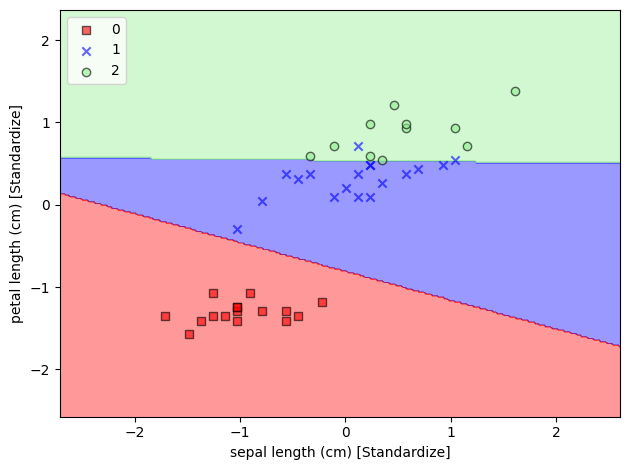

In [22]:
# plot_decision_regions 這個自訂函式吃 numpy array，所以轉成 .values
X_test_std_nd=X_test_std.values
plot_decision_regions(X_test_std_nd, y_test.values, classifier=lr)
plt.xlabel('sepal length (cm) [Standardize]')
plt.ylabel('petal length (cm) [Standardize]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## decision_regions for training data

/Users/wuyichan/IMLP-464/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


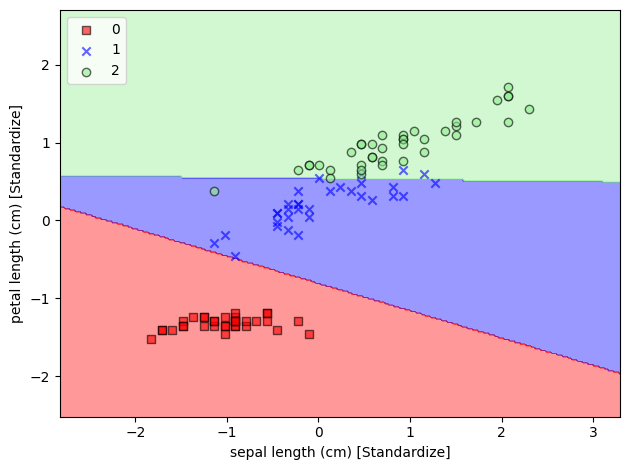

In [23]:
# plot_decision_regions 這個自訂函式吃 numpy array，所以轉成 .values
X_train_std_nd=X_train_std.values
plot_decision_regions(X_train_std_nd, y_train.values, classifier=lr)
plt.xlabel('sepal length (cm) [Standardize]')
plt.ylabel('petal length (cm) [Standardize]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# 9. short conclusion
- Logistic Regression 在 multiclass 問題中可直接使用 lbfgs 求解 multinomial loss
- 特徵標準化後有助於模型訓練穩定
- 使用 pandas index 可更方便追查錯誤樣本